In [1]:
import pandas as pd
import import_ipynb
import nbimporter

from utils import prepareTrainingSet3Sec,standardization,metrics,Grafico_Before_After_Standardization,Grafico_Before_After_GridSearch,Grafico_Tre_Valori,evaluate_Model# type: ignore

from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
import matplotlib.pyplot as plt  
from sklearn.metrics import accuracy_score



BASE 

Eseguo il randomForest senza standardizazione

In [2]:
X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
model=RandomForestClassifier(n_estimators=300, max_depth=6) 
model.fit(X_train, y_train)

    # Valutazione del modello
y_pred = model.predict(X_test)
before_standardization= accuracy_score(y_test, y_pred)
y_pred_train = model.predict(X_train)
evaluate_Model(y_test, y_pred,y_train, y_pred_train)



---------STATISTICHE TEST----------
Accuratezza: 0.6697
Precision: 0.6612
Recall: 0.6702
F1-score: 0.6534
F2-score: 0.6611
---------STATISTICHE TRAING----------
Accuratezza: 0.7232
Precision: 0.7245
Recall: 0.7231
F1-score: 0.7153
F2-score: 0.7184

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


Applichiamo la standardizzazione

In [3]:
X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
X_train, X_test= standardization(X_train, X_test)

model=RandomForestClassifier(n_estimators=300, max_depth=6) 
model.fit(X_train, y_train)
            # Valutazione del modello
y_pred = model.predict(X_test)
after_standardization= accuracy_score(y_test, y_pred)
y_pred_train = model.predict(X_train)

evaluate_Model(y_test, y_pred,y_train, y_pred_train)


---------STATISTICHE TEST----------
Accuratezza: 0.6812
Precision: 0.6742
Recall: 0.6816
F1-score: 0.6670
F2-score: 0.6737
---------STATISTICHE TRAING----------
Accuratezza: 0.7250
Precision: 0.7277
Recall: 0.7248
F1-score: 0.7171
F2-score: 0.7200

=== Analisi ===
Il modello sembra bilanciato e generalizza bene.


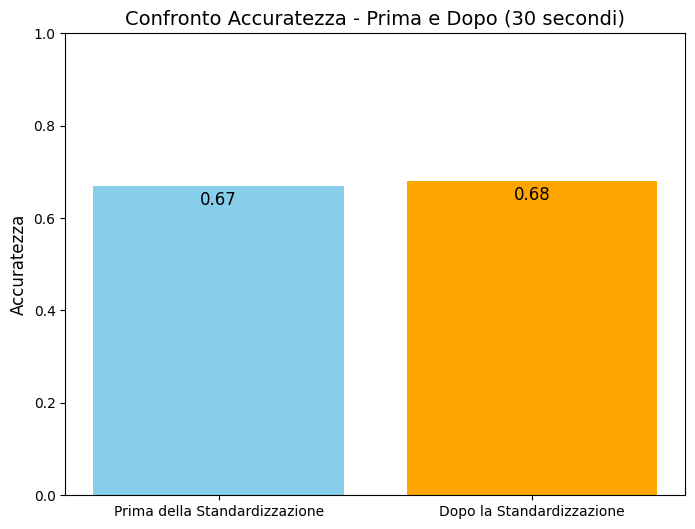

In [4]:
Grafico_Before_After_Standardization(before_standardization, after_standardization)

Uso il gridSearch per ottimizzare i iperparametri e avere delle soluzione migliori

In [6]:


X_train, X_test, y_train, y_test= prepareTrainingSet3Sec()
# utilizzo la funzione di standardizzazzione presente in utils che usa Standard Scaler
X_train, X_test= standardization(X_train, X_test)


# Definizione del modello di Random Forest
rf = RandomForestClassifier(random_state=42)

# Definizione della griglia di parametri
param_grid = {
    'n_estimators': [50, 200],  # Numero di alberi nella foresta
    'max_depth': [20, 30],  # Profondità massima di ciascun albero
    'min_samples_split': [2, 5],  # Minimo numero di campioni richiesti per suddividere un nodo
    'min_samples_leaf': [1, 2],    # Minimo numero di campioni richiesti in una foglia       
}

# Configura GridSearchCV
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=2)

# Esegui la Grid Search
grid_search.fit(X_train, y_train)

# Mostra i migliori parametri trovati
print("Migliori iperparametri trovati:", grid_search.best_params_)

# Valutazione del modello con i migliori parametri
best_rf = grid_search.best_estimator_
y_pred = best_rf.predict(X_test)
after_Grid= accuracy_score(y_test, y_pred)

y_pred_train = best_rf.predict(X_train, y_train)

evaluate_Model(y_test, y_pred,y_train, y_pred_train)


Fitting 5 folds for each of 16 candidates, totalling 80 fits


KeyboardInterrupt: 

In [ ]:
Grafico_Tre_Valori(before_standardization,after_standardization,after_Grid)

NameError: name 'before_3sec_standadization' is not defined